Total spin rows loaded: 900
Sites per configuration: 900
Detected configurations: 1


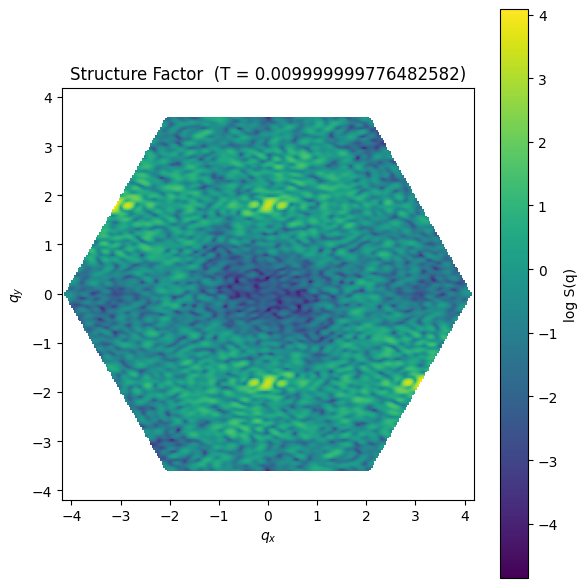

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
filename = "spin_dynamics.txt"     # your data file
T_selected = 0.009999999776482582  # temperature
nq = 250                            # q-grid resolution
average_configs = True              # set False for single snapshot

# =========================
# LOAD DATA
# =========================
data = np.loadtxt(filename, skiprows=1)

t = data[:,0]
i = data[:,1].astype(int)
j = data[:,2].astype(int)
S = data[:,3:6]

mask = np.isclose(t, T_selected)
i, j, S = i[mask], j[mask], S[mask]

print("Total spin rows loaded:", len(S))

# =========================
# BRICK-HONEYCOMB POSITIONS
# =========================
def brick_positions(i, j):
    r = np.zeros((len(i), 2))
    for n, (ii, jj) in enumerate(zip(i, j)):
        ii -= 1
        jj -= 1
        if ii % 2 == 0:
            x = ii
            y = np.sqrt(3)*jj
        else:
            x = ii + 0.5
            y = np.sqrt(3)*jj + np.sqrt(3)/2
        r[n] = [x, y]
    return r

r_all = brick_positions(i, j)

# =========================
# AUTO-DETECT CONFIGURATIONS
# =========================
coords = np.column_stack((i,j))
unique_sites = np.unique(coords, axis=0)
Nsite = len(unique_sites)
Ntotal = len(S)
Nconf = Ntotal // Nsite

print("Sites per configuration:", Nsite)
print("Detected configurations:", Nconf)

# =========================
# STRUCTURE FACTOR
# =========================
def structure_factor(r, S, qx, qy):
    N = len(r)
    Sq = np.zeros((len(qy), len(qx)))
    for ix, qxi in enumerate(qx):
        for iy, qyi in enumerate(qy):
            q = np.array([qxi, qyi])
            phase = np.exp(1j * (r @ q))
            Mq = np.sum(S * phase[:,None], axis=0)
            Sq[iy, ix] = (Mq @ np.conj(Mq)).real / N
    return Sq

# =========================
# Q GRID
# =========================
#qmax = 4.0
#qx = np.linspace(-qmax, qmax, nq)
#qy = np.linspace(-qmax, qmax, nq)
qmax = 4*np.pi/3
qx = np.linspace(-qmax, qmax, nq)
qy = np.linspace(-qmax, qmax, nq)
# =========================
# AVERAGING OVER CONFIGS
# =========================
Sq_total = np.zeros((nq,nq))

n_use = Nconf if average_configs else 1

for c in range(n_use):
    S_conf = S[c*Nsite:(c+1)*Nsite]
    r_conf = r_all[c*Nsite:(c+1)*Nsite]
    Sq_total += structure_factor(r_conf, S_conf, qx, qy)

Sq = Sq_total / n_use

# =========================
# HEXAGONAL MASK
# =========================
def hex_mask(qx, qy):
    mask = np.zeros((len(qy), len(qx)), dtype=bool)
    for ix,x in enumerate(qx):
        for iy,y in enumerate(qy):
            X,Y = abs(x), abs(y)
            if (Y < 2*np.pi/np.sqrt(3)) and (np.sqrt(3)*X + Y < 4*np.pi/np.sqrt(3)):
                mask[iy,ix] = True
    return mask

Sq = np.where(hex_mask(qx,qy), Sq, np.nan)

# =========================
# PLOT
# =========================
plt.figure(figsize=(6,6))
plt.imshow(np.log(Sq+1e-12),
           extent=[qx.min(),qx.max(),qy.min(),qy.max()],
           origin="lower")

plt.xlabel(r"$q_x$")
plt.ylabel(r"$q_y$")
plt.title(f"Structure Factor  (T = {T_selected})")
plt.gca().set_aspect("equal")
plt.colorbar(label="log S(q)")
plt.tight_layout()
plt.show()
